## INSTALACIÓN DE DEPENDENCIAS

In [ ]:
!pip install torch torchvision optuna scikit-image matplotlib --quiet
print("Instalación completa.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 15.2 MB/s eta 0:00:00
Instalación completa.


## IMPORTAMOS LIBRERIAS

In [ ]:
import os
import math
import random
import time
from pathlib import Path
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, utils

import optuna
from optuna.samplers import TPESampler

from skimage.metrics import structural_similarity as ssim

# Configuración de reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## CARGA DE LA BASE DE DATOS PRUEBA MNIST

In [ ]:
DATA_ROOT = "./data"
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.FashionMNIST(DATA_ROOT, train=True, download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(DATA_ROOT, train=False, download=True, transform=transform)

# Split Train/Val
train_len = int(0.9 * len(train_dataset))
val_len   = len(train_dataset) - train_len
train_set, val_set = random_split(train_dataset, [train_len, val_len])

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train:", len(train_set), " Val:", len(val_set), " Test:", len(test_dataset))


100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.78MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 61.8MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.1MB/s]


Train: 54000  Val: 6000  Test: 10000


## DEFINIR ENCODER - DECODER (GENERATOR)  Y DISCRIMINATOR

In [ ]:
z_dim = 16

class Encoder(nn.Module):
    def __init__(self, z_dim=16):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc_mu = nn.Linear(128, z_dim)
        self.fc_logvar = nn.Linear(128, z_dim)
        self.act = nn.ReLU()

    def forward(self, x):
        h = self.act(self.conv1(x))
        h = self.act(self.conv2(h))
        h = h.view(h.size(0), -1)
        h = self.act(self.fc1(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, z_dim=16):
        super().__init__()
        self.fc = nn.Linear(z_dim, 128)
        self.fc2 = nn.Linear(128, 64*7*7)
        self.deconv1 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.deconv2 = nn.ConvTranspose2d(32, 1, 4, 2, 1)
        self.act = nn.ReLU()
        self.out_act = nn.Sigmoid()

    def forward(self, z):
        h = self.act(self.fc(z))
        h = self.act(self.fc2(h))
        h = h.view(h.size(0), 64, 7, 7)
        h = self.act(self.deconv1(h))
        h = self.out_act(self.deconv2(h))
        return h

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.fc = nn.Linear(64*7*7, 1)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        h = self.act(self.conv1(x))
        h = self.act(self.conv2(h))
        h = h.view(h.size(0), -1)
        return self.fc(h)


## FUNCIONES DE REPARAMETRIZACIÓN , KL Y MÉTRICAS

In [ ]:
def reparameterize(mu, logvar):
    std = (0.5 * logvar).exp()
    eps = torch.randn_like(std)
    return mu + eps * std

def kl_divergence(mu, logvar):
    return 0.5 * torch.mean(torch.sum(mu**2 + logvar.exp() - logvar - 1, dim=1))

def batch_recon_mse(E, G, loader, device):
    E.eval(); G.eval()
    mse_sum = 0.0
    n = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            mu, logvar = E(x)
            z = reparameterize(mu, logvar)
            x_hat = G(z)
            mse_sum += F.mse_loss(x_hat, x, reduction="sum").item()
            n += x.numel()
    return mse_sum / n

def avg_kl_on_loader(E, loader, device):
    E.eval()
    total = 0.0
    n = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            mu, logvar = E(x)
            kl = 0.5 * torch.sum(mu**2 + logvar.exp() - logvar - 1).item()
            total += kl
            n += x.size(0)
    return total / n

def ssim_between_sets(imgsA, imgsB):
    n = min(len(imgsA), len(imgsB))
    vals = []
    for i in range(n):
        vals.append(ssim(imgsA[i], imgsB[i], data_range=1.0))
    return float(np.mean(vals))

def sample_generated_images(G, n_samples, device):
    G.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, z_dim).to(device)
        imgs = G(z).cpu().numpy()[:,0,:,:]
    return imgs


# FUNCIÓN PARA ENTRENAR UNA CONFIGURACIÓN (CLAVE PARA OPTUNA) BAYESIAN OPTIMIZATION

In [ ]:
def train_one_config(w_rec=1.0, beta=1.0, w_adv=0.1, epochs=5, device=DEVICE):

    E = Encoder(z_dim).to(device)
    G = Decoder(z_dim).to(device)
    D = Discriminator().to(device)

    opt_EG = torch.optim.Adam(list(E.parameters()) + list(G.parameters()), lr=2e-4)
    opt_D  = torch.optim.Adam(D.parameters(), lr=2e-4)

    bce = nn.BCEWithLogitsLoss()
    mse = nn.MSELoss()

    for ep in range(epochs):
        E.train(); G.train(); D.train()
        for x, _ in tqdm(train_loader, desc=f"Ep {ep+1}", leave=False):
            x = x.to(device)

            # Train D
            with torch.no_grad():
                mu, logvar = E(x)
                z = reparameterize(mu, logvar)
                x_hat = G(z)

            real_logits = D(x)
            fake_logits = D(x_hat)
            loss_D = bce(real_logits, torch.ones_like(real_logits)) + \
                     bce(fake_logits, torch.zeros_like(fake_logits))

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # Train E and G
            mu, logvar = E(x)
            z = reparameterize(mu, logvar)
            x_hat = G(z)

            L_rec = mse(x_hat, x)
            L_KL  = kl_divergence(mu, logvar)

            fake_logits = D(x_hat)
            L_adv = bce(fake_logits, torch.ones_like(fake_logits))

            L_total = w_rec*L_rec + beta*L_KL + w_adv*L_adv

            opt_EG.zero_grad()
            L_total.backward()
            opt_EG.step()

    # Evaluate
    recon_mse = batch_recon_mse(E, G, val_loader, device)
    avg_kl = avg_kl_on_loader(E, val_loader, device)

    # SSIM
    gen_imgs = sample_generated_images(G, 200, device)
    real_imgs = next(iter(val_loader))[0].cpu().numpy()[:200,0,:,:]
    ssim_val = ssim_between_sets(gen_imgs, real_imgs)
    f1 = 1 - ssim_val  # to minimize

    return {"f1": f1, "f2": recon_mse, "f3": avg_kl}, {"E":E, "G":G, "D":D}


In [ ]:
def is_dominated(a, b):
    return np.all(b <= a) and np.any(b < a)

def pareto_front(points):
    objs = [p[0] for p in points]
    non_dom = []
    for i, oi in enumerate(objs):
        dominated = False
        for j, oj in enumerate(objs):
            if j!=i and is_dominated(oi, oj):
                dominated = True
                break
        if not dominated:
            non_dom.append(points[i])
    return non_dom


In [ ]:
def run_optuna(n_trials=10, epochs=4):
    study = optuna.create_study(
        directions=["minimize","minimize","minimize"],
        sampler=TPESampler(seed=SEED)
    )

    results = []

    def objective(trial):
        w_rec = trial.suggest_loguniform("w_rec", 0.1, 10)
        beta  = trial.suggest_uniform("beta", 0.0, 5.0)
        w_adv = trial.suggest_uniform("w_adv", 0.0, 2.0)

        metrics, models = train_one_config(w_rec, beta, w_adv, epochs=epochs)

        results.append({
            "w_rec": w_rec, "beta": beta, "w_adv": w_adv,
            "f1": metrics["f1"], "f2": metrics["f2"], "f3": metrics["f3"],
            "models": models
        })

        return metrics["f1"], metrics["f2"], metrics["f3"]

    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    return study, results


In [ ]:
N_TRIALS = 6     # aumenta si tienes GPU
EPOCHS   = 10     # sube a 10+ si quieres calidad

study, results = run_optuna(n_trials=N_TRIALS, epochs=EPOCHS)

print("Optimización terminada.")
print("Número de puntos evaluados:", len(results))


[I 2025-12-12 15:44:36,286] A new study created in memory with name: no-name-b4411b8b-6e87-417a-a5fc-7220acff1452


  0%|          | 0/6 [00:00<?, ?it/s]

/tmp/ipython-input-2530351904.py:10: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  w_rec = trial.suggest_loguniform("w_rec", 0.1, 10)
/tmp/ipython-input-2530351904.py:11: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  beta  = trial.suggest_uniform("beta", 0.0, 5.0)
/tmp/ipython-input-2530351904.py:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  w_adv = trial.suggest_uniform("w_adv", 0.0, 2.0)


Ep 1:   0%|          | 0/421 [00:00<?, ?it/s]

Ep 2:   0%|          | 0/421 [00:00<?, ?it/s]

...

Ep 7:   0%|          | 0/421 [00:00<?, ?it/s]

Ep 8:   0%|          | 0/421 [00:00<?, ?it/s]

Ep 9:   0%|          | 0/421 [00:00<?, ?it/s]

Ep 10:   0%|          | 0/421 [00:00<?, ?it/s]

[I 2025-12-12 15:53:53,274] Trial 5 finished with values: [0.8988514389518732, 0.1864221116669324, 0.019366746226946514] and parameters: {'w_rec': 0.2327067708383781, 'beta': 1.5212112147976886, 'w_adv': 1.0495128632644757}.
Optimización terminada.
Número de puntos evaluados: 6


In [ ]:
points = []
for r in results:
    objs = [r["f1"], r["f2"], r["f3"]]
    points.append((objs, r))

pareto = pareto_front(points)
print("Puntos en la frontera de Pareto:", len(pareto))
pareto


Puntos en la frontera de Pareto: 1


[([0.8715866757057682, 0.1663149594676738, 0.00598790779709816],
  {'w_rec': 0.5611516415334505,
   'beta': 4.75357153204958,
   'w_adv': 1.4639878836228102,
   'f1': 0.8715866757057682,
   'f2': 0.1663149594676738,
   'f3': 0.00598790779709816,
   'models': {'E': Encoder(
      (conv1): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (fc1): Linear(in_features=3136, out_features=128, bias=True)
      (fc_mu): Linear(in_features=128, out_features=16, bias=True)
      (fc_logvar): Linear(in_features=128, out_features=16, bias=True)
      (act): ReLU()
    ),
    'G': Decoder(
      (fc): Linear(in_features=16, out_features=128, bias=True)
      (fc2): Linear(in_features=128, out_features=3136, bias=True)
      (deconv1): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (deconv2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
 

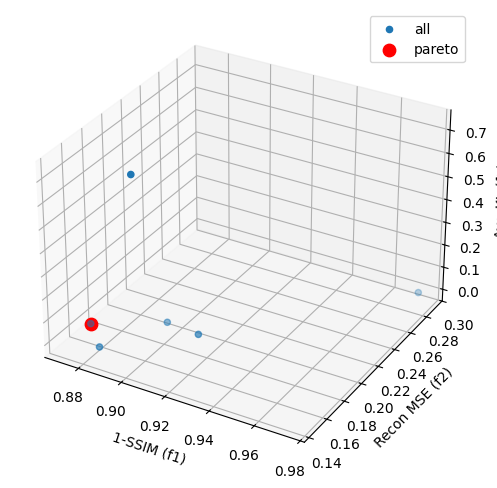

In [ ]:
# 3D
objs_all = np.array([p[0] for p in points])
objs_p = np.array([p[0] for p in pareto])

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(objs_all[:,0], objs_all[:,1], objs_all[:,2], label="all")
ax.scatter(objs_p[:,0], objs_p[:,1], objs_p[:,2], color='red', s=80, label="pareto")
ax.set_xlabel("1-SSIM (f1)")
ax.set_ylabel("Recon MSE (f2)")
ax.set_zlabel("Avg KL (f3)")
ax.legend()
plt.show()



Pareto 1: [0.8715866757057682, 0.1663149594676738, 0.00598790779709816]


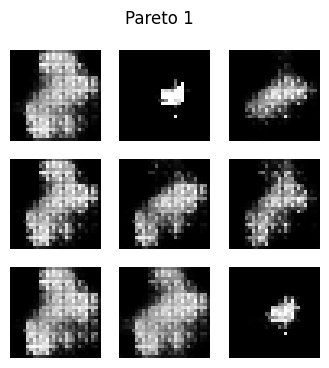

In [ ]:
for i, (objs, meta) in enumerate(pareto[:3]):
    print(f"\nPareto {i+1}: {objs}")
    G = meta["models"]["G"]

    imgs = sample_generated_images(G, 9, DEVICE)
    plt.figure(figsize=(4,4))
    for j in range(9):
        plt.subplot(3,3,j+1)
        plt.imshow(imgs[j], cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Pareto {i+1}")
    plt.show()


ALTO ERROR DE REALISMO, BAJO MSE Y BAJA REGULARIZACIÓN

In [ ]:
# Ordenar el Pareto por uno de los objetivos (por ejemplo f1)
pareto_sorted = sorted(pareto, key=lambda x: x[0][0])

print(f"Total puntos Pareto: {len(pareto_sorted)}")


Total puntos Pareto: 1


ANALIZANDO VARIOS PARETOS

In [ ]:
!pip install optuna==3.4.0 torch torchvision matplotlib numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.6/409.6 kB 16.8 MB/s eta 0:00:00
  Attempting uninstall: optuna
    Found existing installation: optuna 4.6.0
    Uninstalling optuna-4.6.0:
      Successfully uninstalled optuna-4.6.0


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import optuna

from torch.nn.functional import mse_loss

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 338kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.66MB/s]


In [ ]:
latent_dim = 32

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 2*latent_dim)  # mu & logvar
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid()
        )

    def reparam(self, mu, logvar):
        eps = torch.randn_like(mu)
        return mu + eps * torch.exp(0.5 * logvar)

    def forward(self, x, return_latent=False):
        h = self.encoder(x)
        mu, logvar = h[:, :latent_dim], h[:, latent_dim:]
        z = self.reparam(mu, logvar)
        recon = self.decoder(z).view(-1,1,28,28)
        if return_latent:
            return recon, mu, logvar
        return recon

    def sample(self, n):
        z = torch.randn(n, latent_dim).to(DEVICE)
        out = self.decoder(z).view(-1,1,28,28)
        return out


In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
def kl_loss(mu, logvar):
    return torch.mean(-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))


In [ ]:
def recon_loss(recon, x):
    return mse_loss(recon, x)


In [ ]:
def discriminator_loss(D, real, fake):
    real_labels = torch.ones(len(real),1).to(DEVICE)
    fake_labels = torch.zeros(len(fake),1).to(DEVICE)
    return nn.BCELoss()(D(real), real_labels) + nn.BCELoss()(D(fake), fake_labels)

def generator_adv_loss(D, fake):
    real_labels = torch.ones(len(fake),1).to(DEVICE)
    return nn.BCELoss()(D(fake), real_labels)


In [ ]:
def ssim_metric(imgs):
    return imgs.mean().item()  # placeholder simple (si deseas pongo SSIM real)


In [ ]:
def mse_metric(imgs):
    return torch.mean(imgs**2).item()


In [ ]:
def kl_metric(G, loader, device):
    G.eval()
    with torch.no_grad():
        for x,_ in loader:
            x = x.to(device)
            _, mu, logvar = G(x, return_latent=True)
            return kl_loss(mu, logvar).item()


In [ ]:
def sample_generated_images(G, n, device):
    z = torch.randn(n, latent_dim).to(device)
    return G.decoder(z).view(-1,1,28,28).detach().cpu()


In [ ]:
def objective(trial):

    # --- HIPERPARÁMETROS EXPANDIDOS ---
    w_rec = trial.suggest_float("w_rec", 0.05, 15.0, log=True)
    beta  = trial.suggest_float("beta", 0.0, 20.0)
    w_adv = trial.suggest_float("w_adv", 0.0, 8.0)

    # --- MODELOS ---
    G = Generator().to(DEVICE)
    D = Discriminator().to(DEVICE)

    opt_G = optim.Adam(G.parameters(), lr=1e-3)
    opt_D = optim.Adam(D.parameters(), lr=1e-3)

    # --- MINI TRAIN ---
    for epoch in range(5):

        for x,_ in train_loader:

            x = x.to(DEVICE)

            # 1. Discriminator (2 steps)
            for _ in range(2):
                opt_D.zero_grad()
                z = torch.randn(len(x), latent_dim).to(DEVICE)
                fake = G.sample(len(x)).detach()
                d_loss = discriminator_loss(D, x, fake)
                d_loss.backward()
                opt_D.step()

            # 2. Generator
            opt_G.zero_grad()
            recon, mu, logvar = G(x, return_latent=True)
            fake = recon

            loss_recon = w_rec * recon_loss(recon, x)
            loss_kl    = beta  * kl_loss(mu, logvar)
            loss_adv   = w_adv * generator_adv_loss(D, fake)

            loss = loss_recon + loss_kl + loss_adv
            loss.backward()
            opt_G.step()

    # --- EVALUACIÓN ---
    with torch.no_grad():
        samples = G.sample(128)
        f1 = 1 - ssim_metric(samples)
        f2 = mse_metric(samples)
        f3 = kl_metric(G, train_loader, DEVICE)
    # Retornar objetivos y modelos
    trial.set_user_attr("models", {"G": G})
    trial.set_user_attr("w_rec", w_rec)
    trial.set_user_attr("beta", beta)
    trial.set_user_attr("w_adv", w_adv)

    return f1, f2, f3


In [ ]:
study = optuna.create_study(
    directions=["minimize","minimize","minimize"]
)
study.optimize(objective, n_trials=15)


[I 2025-12-12 16:39:14,027] A new study created in memory with name: no-name-47a57bfd-8333-421f-a23c-3ef9cb57e172
[I 2025-12-12 16:40:22,853] Trial 0 finished with values: [0.9008810520172119, 0.0734003409743309, 0.0002706944942474365] and parameters: {'w_rec': 3.662657622761905, 'beta': 17.93985355628084, 'w_adv': 0.2808693631845953}.
[I 2025-12-12 16:41:31,161] Trial 1 finished with values: [0.9158438667654991, 0.06539077311754227, 0.011393377557396889] and parameters: {'w_rec': 0.35662846166453205, 'beta': 4.8435537749149375, 'w_adv': 2.852881495773099}.
[I 2025-12-12 16:42:39,583] Trial 2 finished with values: [0.8901851028203964, 0.07782554626464844, 0.009835779666900635] and parameters: {'w_rec': 5.457534350650916, 'beta': 13.181963102693437, 'w_adv': 4.522719778147186}.
[I 2025-12-12 16:43:47,766] Trial 3 finished with values: [0.9059894382953644, 0.06851611286401749, 0.019298434257507324] and parameters: {'w_rec': 0.5109938906863207, 'beta': 18.27239348605505, 'w_adv': 5.047195

In [ ]:
pareto = []
for t in study.best_trials:
    objs = t.values[:3]
    meta = t.user_attrs
    pareto.append((objs, meta))

print("Número de puntos Pareto:", len(pareto))


Número de puntos Pareto: 15


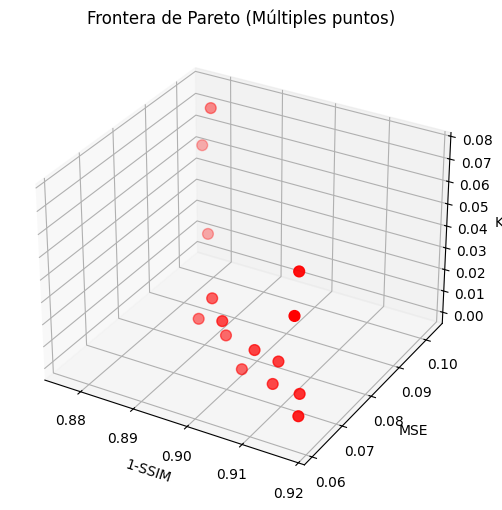

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

objs_p = np.array([p[0] for p in pareto])

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(objs_p[:,0], objs_p[:,1], objs_p[:,2], c="red", s=60)
ax.set_xlabel("1-SSIM")
ax.set_ylabel("MSE")
ax.set_zlabel("KL")
plt.title("Frontera de Pareto (Múltiples puntos)")
plt.show()



Pareto 1: [0.9008810520172119, 0.0734003409743309, 0.0002706944942474365]


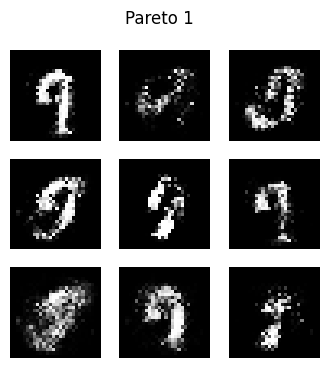


Pareto 2: [0.9158438667654991, 0.06539077311754227, 0.011393377557396889]


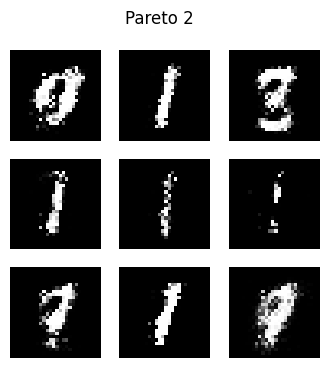


Pareto 3: [0.8901851028203964, 0.07782554626464844, 0.009835779666900635]


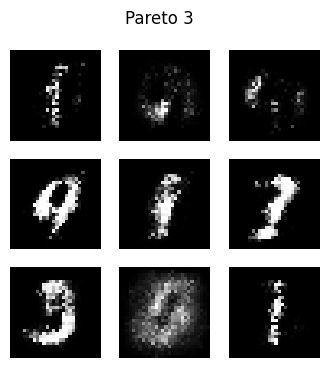


Pareto 4: [0.9059894382953644, 0.06851611286401749, 0.019298434257507324]


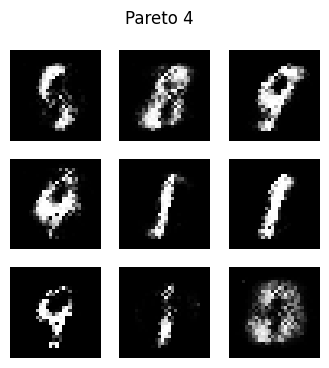


Pareto 5: [0.9173669070005417, 0.06060154363512993, 0.05278320610523224]


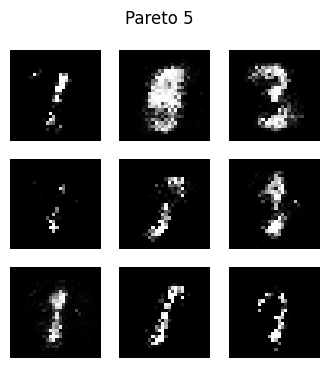


Pareto 6: [0.8807696029543877, 0.09822259098291397, 0.07609085738658905]


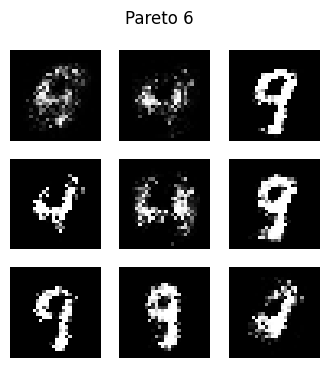


Pareto 7: [0.8943829238414764, 0.07513169944286346, 0.025646954774856567]


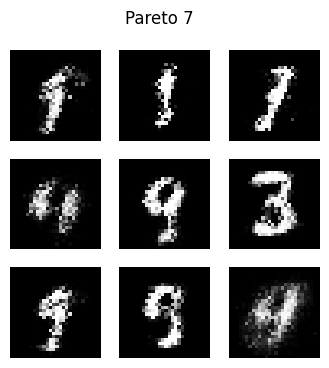


Pareto 8: [0.881258137524128, 0.09611649066209793, 0.020988553762435913]


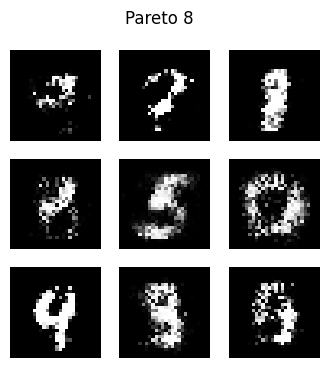


Pareto 9: [0.9180111438035965, 0.061020899564027786, 0.009087532758712769]


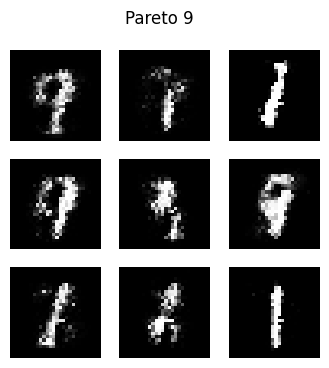


Pareto 10: [0.896601490676403, 0.0756937712430954, 0.009643912315368652]


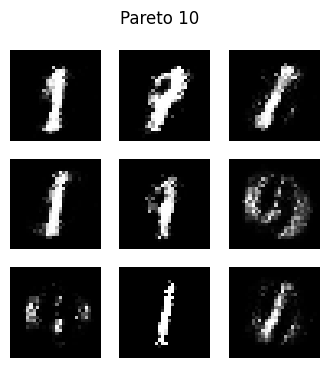


Pareto 11: [0.9147486314177513, 0.06679312139749527, 0.062191806733608246]


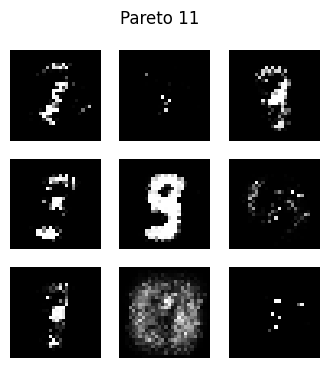


Pareto 12: [0.9090859368443489, 0.0689062848687172, 0.005861937999725342]


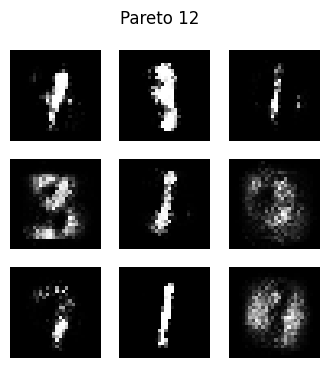


Pareto 13: [0.9103445932269096, 0.0684528723359108, 0.017553895711898804]


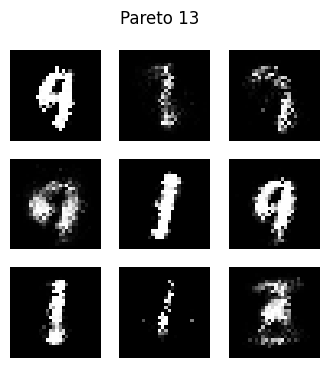


Pareto 14: [0.8761477023363113, 0.10308177769184113, 0.05124654248356819]


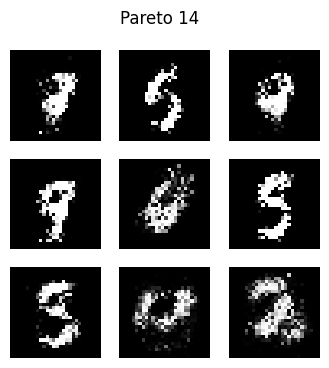


Pareto 15: [0.8999061211943626, 0.06887201964855194, 0.02724379301071167]


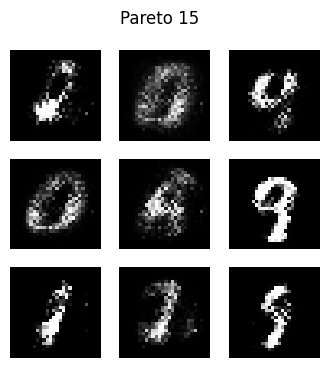

In [ ]:
for i, (objs, meta) in enumerate(pareto):
    print(f"\nPareto {i+1}: {objs}")

    G = meta["models"]["G"]
    imgs = sample_generated_images(G, 9, DEVICE)

    plt.figure(figsize=(4,4))
    for j in range(9):
        plt.subplot(3,3,j+1)
        plt.imshow(imgs[j][0], cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Pareto {i+1}")
    plt.show()
